____
# BIOSWOT : Sensitivity to stain and vorticity


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance_groupby, compute_variance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Characteritics :
- from April 20th to 18th (cycle 497-515)
- 4-5°E; 40.3-41.3°N
- move from W to E
- size ?

In [60]:
def sel_fastswot(dfr):
    c1, c2 = 501, 524
    id = dfr[(dfr.longitude>1.25)&(dfr.longitude<2)&(dfr.latitude>39.5)&(dfr.latitude<40)&(dfr.cycle_number>c1)&(dfr.cycle_number<c2)].drifter_id.unique()
    
    dfr = dfr[((dfr.drifter_id.isin(id))
               &(dfr.longitude>1.25)
               &(dfr.longitude<2)
               &(dfr.latitude>39.5)
               &(dfr.latitude<40)
               &(dfr.cycle_number>c1)
               &(dfr.cycle_number<c2)
               #&(~((dfr.longitude<4.75)&(dfr.latitude<40.6)))
              )]
    return dfr

def generate_0_15m_coloc_dataframe(freq_band):
    
    DT = 12
    
    # SURFACE
    base_dic = dict(dt='12h', 
            drifter_preprocess = 'spectral_decomp',
            drifter_preprocess_param= freq_band,
            alti_product_key='swot2km',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '0')
    
    
    comb_list = [base_dic]
    
    
    ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
    ds0 = ds0.where(ds0.depth==0, drop=True)
    #distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
    #ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
    #ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    #ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
    #ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)
    
    df0 = ds0.to_dataframe().reset_index().set_index('row_number')
    
    #DEPTH 15M
    base_dic = dict(dt='12h', 
                drifter_preprocess = 'spectral_decomp',
                drifter_preprocess_param=freq_band,
                alti_product_key='swot2km',
                alti_diff_method = 'fromduacsv',
                alti_diff_method_param = '',
                ggd_var = 'fromduacsv',
                wd_product_key = 'era5', 
                wd_model ='rio', 
                wd_depth = '15')
    
    comb_list = [    
        base_dic, 
    ]
    
    ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
    ds15 =ds15.where(ds15.depth==15, drop=True)
    #distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
    #ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
    ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    #ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
    #ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)
    
    df15 = ds15.to_dataframe().reset_index().set_index('row_number')

    return df0, df15

# SWOT

In [61]:
bbox = [1.25, 2, 39.5, 40]

product = 'swot2km'
dss16 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass16_{product}_general.nc'))
dss16 = xr.merge([dss16,  xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'diff_only', f'pass16_{product}_diff_only.nc'))], compat='override')
dss16= dss16.where(dss16.distance_to_coast>20e3, drop=True)
dss16 = dss16.sel(cycle_number= slice(501, 525))
dss16 = dss16.where((dss16.longitude>1.25)&(dss16.longitude<2)&(dss16.latitude>39.5)&(dss16.latitude<40), drop=True)
dss16['time'] = (dss16.time - np.timedelta64(946684800000000000, 'ns'))

dfr = prepared_drifters('12h', drifter_preprocess = 'spectral_decomp', drifter_preprocess_param='inertial')
dfr = sel_fastswot(dfr)

depthcolor = {0:'navy', 15:'green', 50:'yellowgreen', 100:'yellow'}
dfr['depthcolor'] = [depthcolor[d] for d in dfr.depth] 


era = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'wind', 'era5_agesc_rio_z0.nc'))


<Axes: xlabel='longitude', ylabel='latitude'>

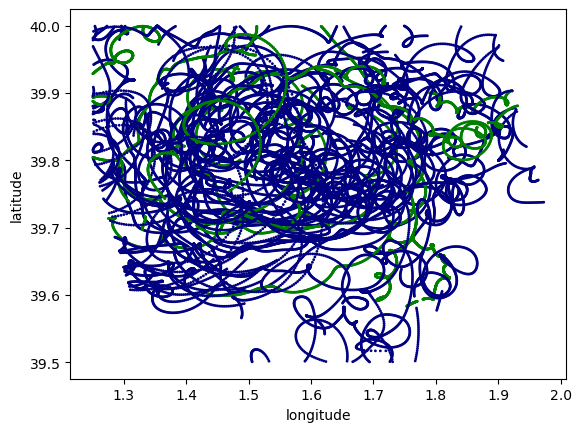

In [62]:
dfr.plot.scatter('longitude', 'latitude', c=dfr.depthcolor, s=1)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


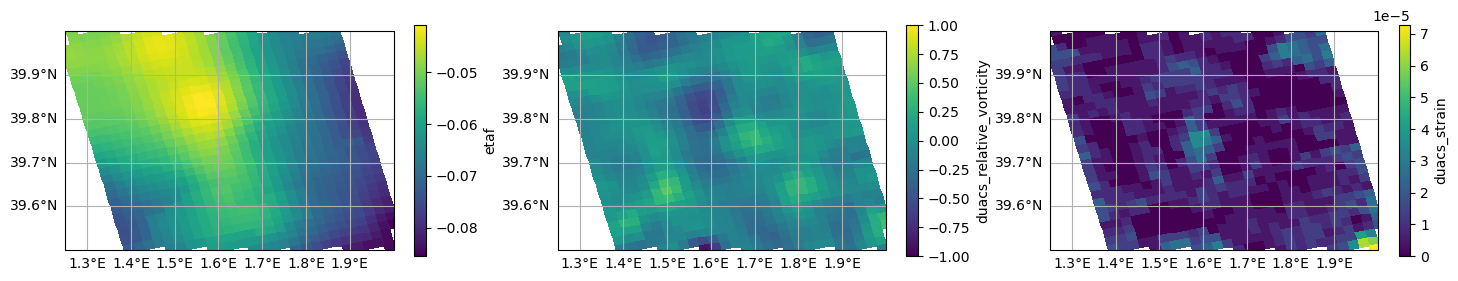

In [63]:
fig, axs = plt.subplots(1, 3, figsize=(18,3), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), sharey=True)

ax=axs[0]
kw = dict(transform=crs)
dss16.etaf.mean('cycle_number').plot(x='longitude', y='latitude',ax=ax, **kw)

ax=axs[1]
kw = dict(transform=crs, vmin = -1, vmax = 1)
dss16.duacs_relative_vorticity.mean('cycle_number').plot(x='longitude', y='latitude',ax=ax, **kw)

ax=axs[2]
#kw = dict(vmin = 0, vmax = 1e-4)
dss16.duacs_strain.mean('cycle_number').plot(x='longitude', y='latitude', ax=ax)#, **kw)

for ax in axs :
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False

# Drifters
- surface and 15m drifters = different behaviour
- strong inertia after wind blows on ...

In [64]:
dss16.sizes['cycle_number']

23

In [65]:
len(dfr.cycle_number.unique())

20

In [66]:
len(dfr.drifter_id.unique())

45

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


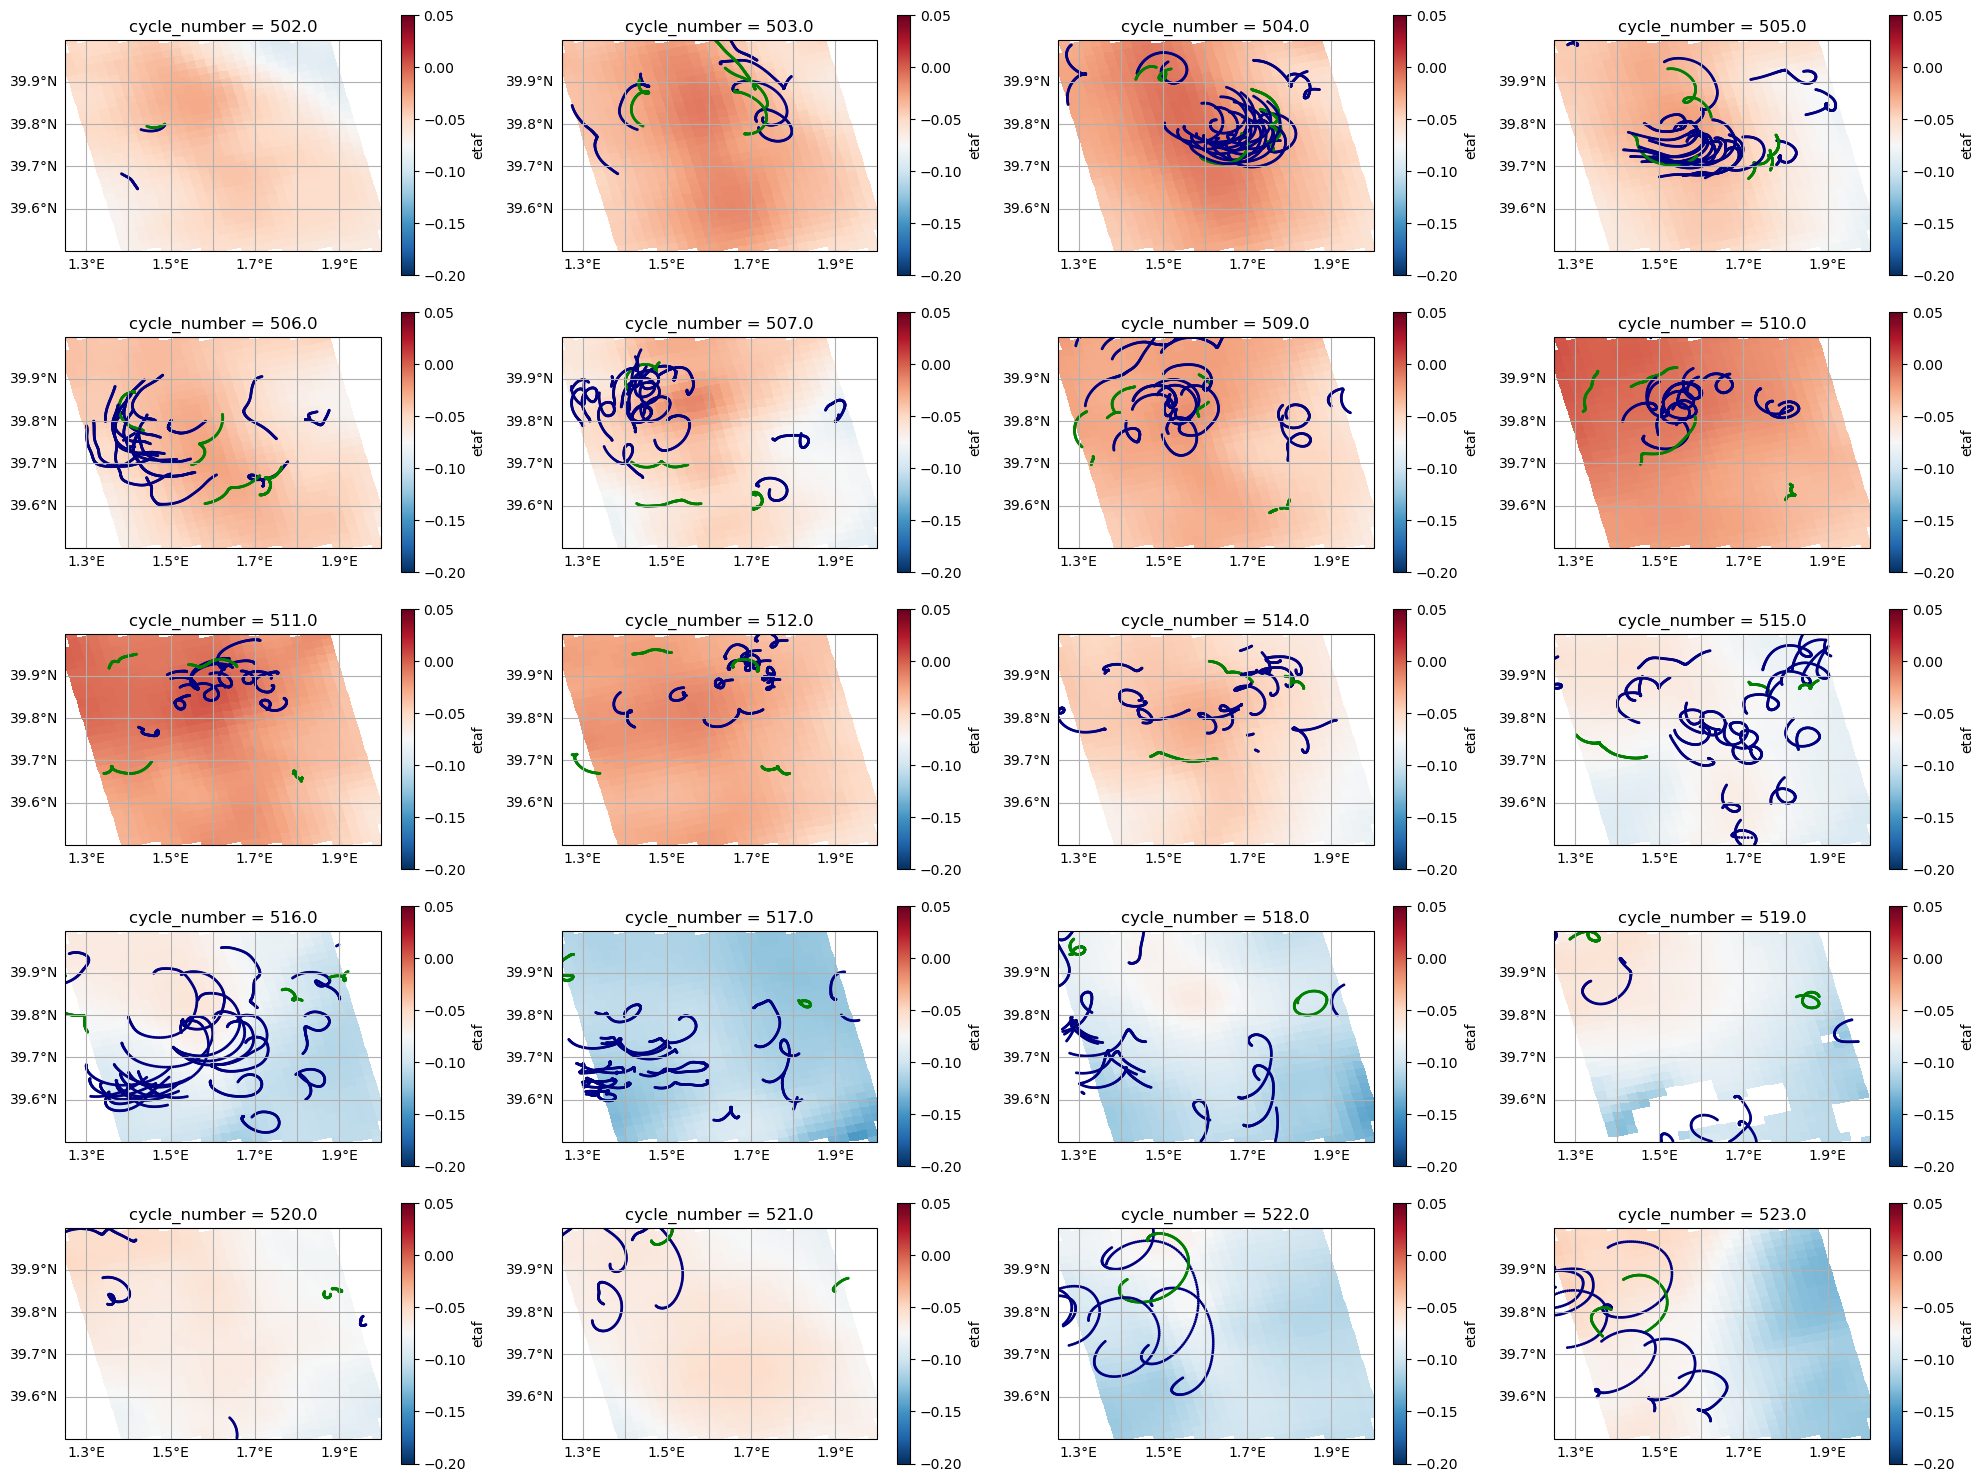

In [69]:
fig, axs = plt.subplots(5, 4, figsize=(20,15), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

kw = dict(transform=crs, cmap='RdBu_r', vmin=-0.2, vmax=0.05)
i=0
for c in dfr.cycle_number.unique() :

    ax=axs[i]
    dss16.etaf.sel(cycle_number=int(c)).plot(x='longitude', y='latitude',ax=ax, **kw)
    dfr_ = dfr[dfr.cycle_number==c]
    dfr_.plot.scatter( 'longitude', 'latitude',ax=ax, s=1, transform=crs, c=dfr_.depthcolor)
    i+=1

for ax in axs :
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False

fig.tight_layout()

In [71]:
df0, df15 = generate_0_15m_coloc_dataframe('')
dfs = prepared_alti(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'xarray_diff' ,
        alti_diff_method_param = '')

def concat(df, dfs):
    df = pd.concat([df, dfs[['vorticity_etaf', 'strain_s_etaf', 'strain_n_etaf',]]], axis=1).dropna()
    df['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
    fo = df.f.mean()
    df['strain_f'] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
    df['strain'] = df.strain_f*df.f#.assign_attrs({'long_name':r'$\sigma/|f|$'})
    df['vorticity'] = df.vorticity_etaf*df.f#.assign_attrs({'long_name':r'$\zeta/f$'})
    df['vorticity_f'] = df.vorticity_etaf#.assign_attrs({'long_name':r'$\zeta/f$'})
    df['omega'] = df.strain**2 - df.vorticity**2
    return df


df0 = sel_fastswot(concat(df0, dfs))
df15 = sel_fastswot(concat(df15, dfs))

321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


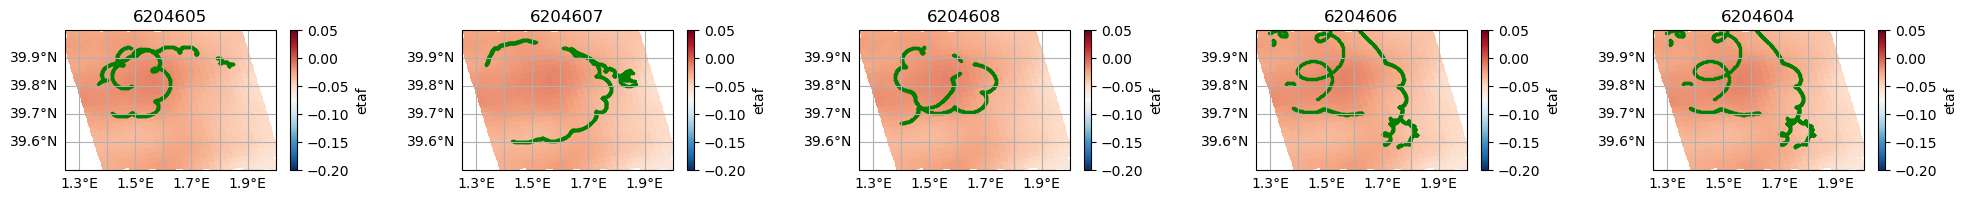

In [76]:
did = df15.drifter_id.unique()
fig, axs = plt.subplots(len(did)//5, 5, figsize=(20,2), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()))
axs=axs.flatten()
for i in range(len(did)):
    ax=axs[i]
    kw = dict(transform=crs, cmap='RdBu_r', vmin=-0.2, vmax=0.05)
    dss16.sel(cycle_number=512).etaf.plot(x='longitude', y='latitude', ax=ax, **kw)
    df15[df15.drifter_id == did[i]].set_index('datetime').plot.scatter(x='longitude', y='latitude', s=2, ax=ax, transform=crs, color=depthcolor[15])
    ax.set_title(did[i])
for ax in axs :
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False

fig.tight_layout()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


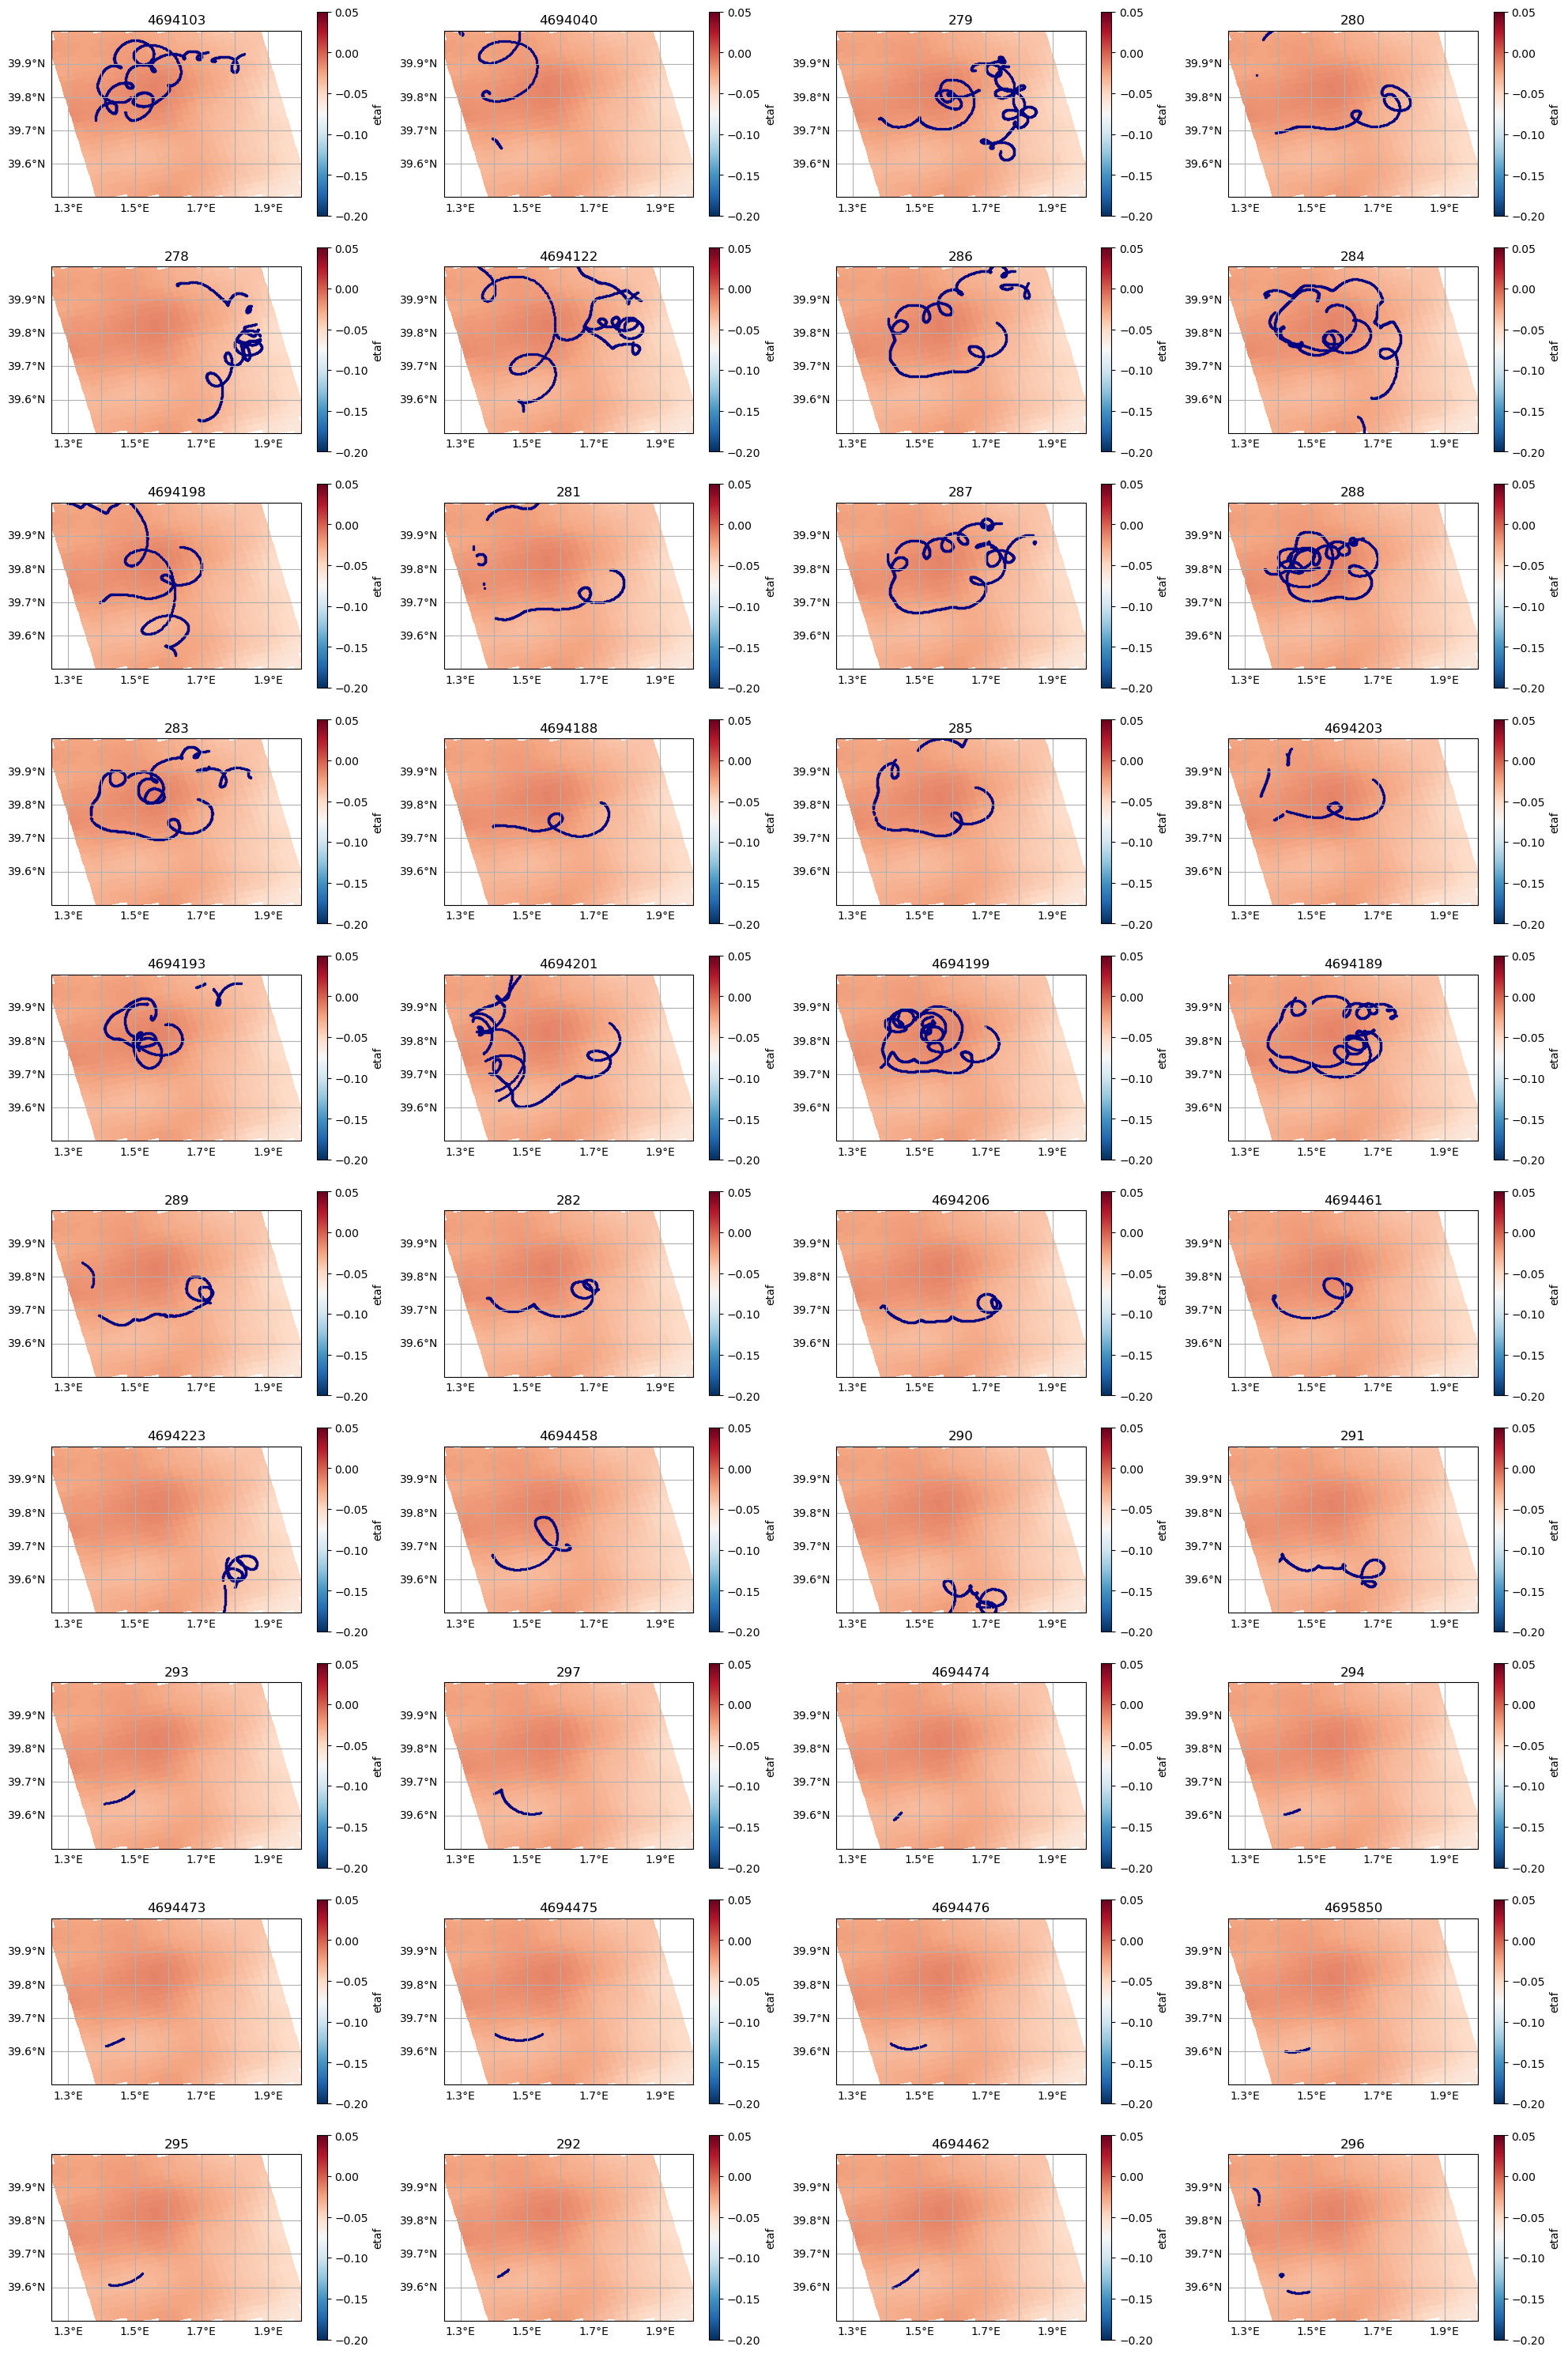

In [77]:
did = df0.drifter_id.unique()
fig, axs = plt.subplots(len(did)//4+1, 4, figsize=(20,30), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()))
axs=axs.flatten()
for i in range(len(did)):
    ax=axs[i]
    kw = dict(transform=crs, cmap='RdBu_r', vmin=-0.2, vmax=0.05)
    dss16.sel(cycle_number=512).etaf.plot(x='longitude', y='latitude', ax=ax, **kw)
    df0[df0.drifter_id == did[i]].set_index('datetime').plot.scatter(x='longitude', y='latitude', s=2, ax=ax, transform=crs, color=depthcolor[0])
    ax.set_title(did[i])
for ax in axs :
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False

fig.tight_layout()

# Inertia : Wind/inertial component of drifters
- QUID other components ??

In [78]:
era = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'wind', 'era5_agesc_rio_z0.nc'))
era = era.where((era.longitude>1.25)&(era.longitude<2)&(era.latitude>39.5)&(era.latitude<40), drop=True)  
era = era.sel(time = slice(dss16.time.min().values, dss16.time.max().values))

In [79]:
dt_bin = '6h'

dfr['acc'] = np.sqrt(dfr.acce**2 +dfr.accn**2)
dfr['cor'] = np.sqrt(dfr.core**2 +dfr.corn**2)
dfr['time_sec'] = (dfr.datetime-dfr.datetime.min())/pd.Timedelta(dt_bin)//1

dfr0 = dfr[dfr.depth==0]
dfr15 = dfr[dfr.depth==15]

def give_acc(dfr):
    acc = dfr.groupby('time_sec')[['acc', 'cor']].mean().reset_index()
    acc['time'] = acc.time_sec*pd.Timedelta(dt_bin) + dfr.datetime.min()
    #acc['time'] = dss16.sel(cycle_number = acc.index.values).time.mean('num_lines').values
    from cstes import U, c0
    return acc.set_index('time')/U

acc0  = give_acc(dfr0)
acc15  = give_acc(dfr15)

In [80]:
dfr.columns

Index(['datetime', 'longitude', 'latitude', 'pass_number', 'depth',
       'time_to_swot', 'cycle_number', 'cycle_date', 'drifter_id',
       'drifter_type', 'accn', 'acce', 'core', 'corn', 'depthcolor', 'acc',
       'cor', 'time_sec'],
      dtype='object')

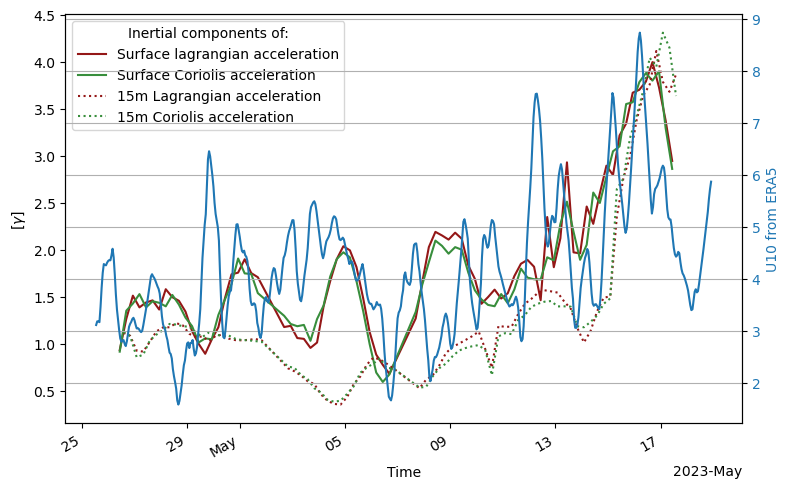

In [84]:
fig, ax = plt.subplots(figsize = (8, 5), frameon=False)

(acc0.acc).plot(label='Surface lagrangian acceleration', ax=ax, color = c0['acc'])
(acc0.cor).plot(label='Surface Coriolis acceleration', ax=ax, color = c0['cor'])
(acc15.acc).plot(label='15m Lagrangian acceleration', ax=ax, color = c0['acc'], ls=':')
(acc15.cor).plot(label='15m Coriolis acceleration', ax=ax, color = c0['cor'], ls=':')
ax.set_ylabel(r'[$\gamma$]')
ax.legend(title='Inertial components of:')
ax.set_xlabel('Time')

ax = ax.twinx()  # instantiate a second Axes that shares the same x-axis
(era.U10.rolling(time=12, center=True).mean('time').mean(['longitude', 'latitude'])).plot(ax=ax, label='U10 from ERA5')
ax.grid()
ax.tick_params(axis='y', labelcolor='tab:blue')
ax.set_ylabel('U10 from ERA5', color='tab:blue') 
ax.set_xlabel('Time')

fig.tight_layout()

# LF : Diagram vorticity strain + total reconstrcution -> Cyclogeostrophy

In [85]:
df0, df15 = generate_0_15m_coloc_dataframe('LF')
dfs = prepared_alti(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'xarray_diff' ,
        alti_diff_method_param = '')

def concat(df, dfs):
    df = pd.concat([df, dfs[['vorticity_etaf', 'strain_s_etaf', 'strain_n_etaf',]]], axis=1).dropna()
    df['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
    fo = df.f.mean()
    df['strain_f'] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
    df['strain'] = df.strain_f*df.f#.assign_attrs({'long_name':r'$\sigma/|f|$'})
    df['vorticity'] = df.vorticity_etaf*df.f#.assign_attrs({'long_name':r'$\zeta/f$'})
    df['vorticity_f'] = df.vorticity_etaf#.assign_attrs({'long_name':r'$\zeta/f$'})
    df['omega'] = df.strain**2 - df.vorticity**2
    return df


df0 = sel_fastswot(concat(df0, dfs))
df15 = sel_fastswot(concat(df15, dfs))

321898
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [86]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    from matplotlib import colors
    da.plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0, add_colorbar=False,)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    return fig, ax, ax_histx, ax_histy
    #fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

def plot_join_pdfs_one(ds, x, y, binx=100, biny=100, ax=None):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x], coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    
    from matplotlib import colors
    da.where(da!=0).plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ax.grid()
    


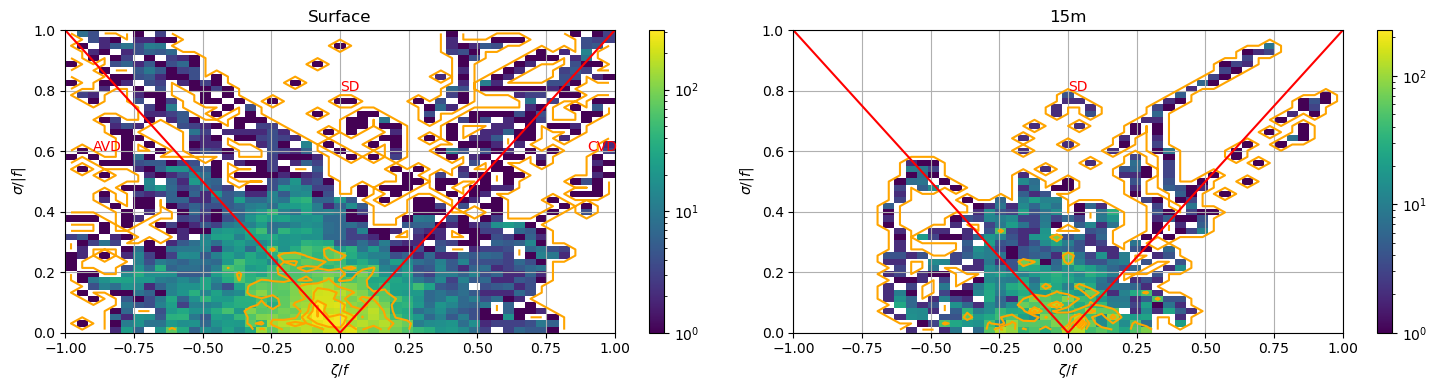

In [87]:
fig, axs = plt.subplots(1, 2, figsize =(15, 4), frameon=False)

ax=axs[0]
plot_join_pdfs_one(df0, 'vorticity_f', 'strain_f', binx=np.linspace(-1, 1, 50), biny=np.linspace(0, 1,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
#rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
#ax.add_patch(rect)

ax.annotate('AVD', (-0.9, 0.6), c='r')
ax.annotate('SD', (0, 0.8), c='r')
ax.annotate('CVD', (0.9, 0.6), c='r')

ax.set_title('Surface')

ax=axs[1]
plot_join_pdfs_one(df15, 'vorticity_f', 'strain_f', binx=np.linspace(-1, 1, 50), biny=np.linspace(0, 1,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
#rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
#ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 0.8), c='r')
ax.annotate('CVD', (1.3, 0.6), c='r')

ax.set_title('15m')

fig.tight_layout()

In [88]:
df0_ = df0[~((abs(df0.vorticity_f)<=0.35)&(df0.strain_f<=0.35))]
df0_ = df0_[~((df0.vorticity_f<=df0.strain_f+0.15)&(df0.vorticity_f>=df0.strain_f-0.15))]
df0_ = df0_[~((df0.vorticity_f<=-df0.strain_f+0.15)&(df0.vorticity_f>=-df0.strain_f-0.15))]
df15_ = df15[~((abs(df15.vorticity_f)<=0.35)&(df15.strain_f<=0.35))]
df15_ = df15_[~((df15.vorticity_f<=df15.strain_f+0.15)&(df15.vorticity_f>=df15.strain_f-0.15))]
df15_ = df15_[~((df15.vorticity_f<=-df15.strain_f+0.15)&(df15.vorticity_f>=-df15.strain_f-0.15))]


/dev/shm/pbs.3523628.datarmor0/ipykernel_411/4137821532.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df0_ = df0_[~((df0.vorticity_f<=df0.strain_f+0.15)&(df0.vorticity_f>=df0.strain_f-0.15))]
/dev/shm/pbs.3523628.datarmor0/ipykernel_411/4137821532.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df0_ = df0_[~((df0.vorticity_f<=-df0.strain_f+0.15)&(df0.vorticity_f>=-df0.strain_f-0.15))]
/dev/shm/pbs.3523628.datarmor0/ipykernel_411/4137821532.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df15_ = df15_[~((df15.vorticity_f<=df15.strain_f+0.15)&(df15.vorticity_f>=df15.strain_f-0.15))]
/dev/shm/pbs.3523628.datarmor0/ipykernel_411/4137821532.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df15_ = df15_[~((df15.vorticity_f<=-df15.strain_f+0.15)&(df15.vorticity_f>=-df15.strain_f-0.15))]


In [89]:
DSz0 = {'AVD': df0_[(df0_.vorticity<0) & (df0_.strain<abs(df0_.vorticity))].to_xarray(), 
       'CVD': df0_[(df0_.vorticity>0) & (df0_.strain<abs(df0_.vorticity))].to_xarray(), 
       'SD': df0_[df0_.strain>=abs(df0_.vorticity)].to_xarray()}

DSz15 = {'AVD': df15_[(df15_.vorticity<0) & (df15_.strain<abs(df15_.vorticity))].to_xarray(), 
       'CVD': df15_[(df15_.vorticity>0) & (df15_.strain<abs(df15_.vorticity))].to_xarray(), 
       'SD': df15_[df15_.strain>=abs(df15_.vorticity)].to_xarray()}

/dev/shm/pbs.3523628.datarmor0/ipykernel_411/3761281142.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])
/dev/shm/pbs.3523628.datarmor0/ipykernel_411/3761281142.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])


516
106


/dev/shm/pbs.3523628.datarmor0/ipykernel_411/3761281142.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])


526
2.0816615946027555
2.098547779724856
2.922856071277453
3.2537116637291095
3.442445233688727
3.5788823854470393
2849


/dev/shm/pbs.3523628.datarmor0/ipykernel_411/3761281142.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz0[k].dims['row_number'])
/dev/shm/pbs.3523628.datarmor0/ipykernel_411/3761281142.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz0[k].dims['row_number'])


1012
1303


/dev/shm/pbs.3523628.datarmor0/ipykernel_411/3761281142.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz0[k].dims['row_number'])


4.163862498788009
4.426152933005427
5.52207889894986
5.758929405496616
5.515017846472335
5.98699419339276


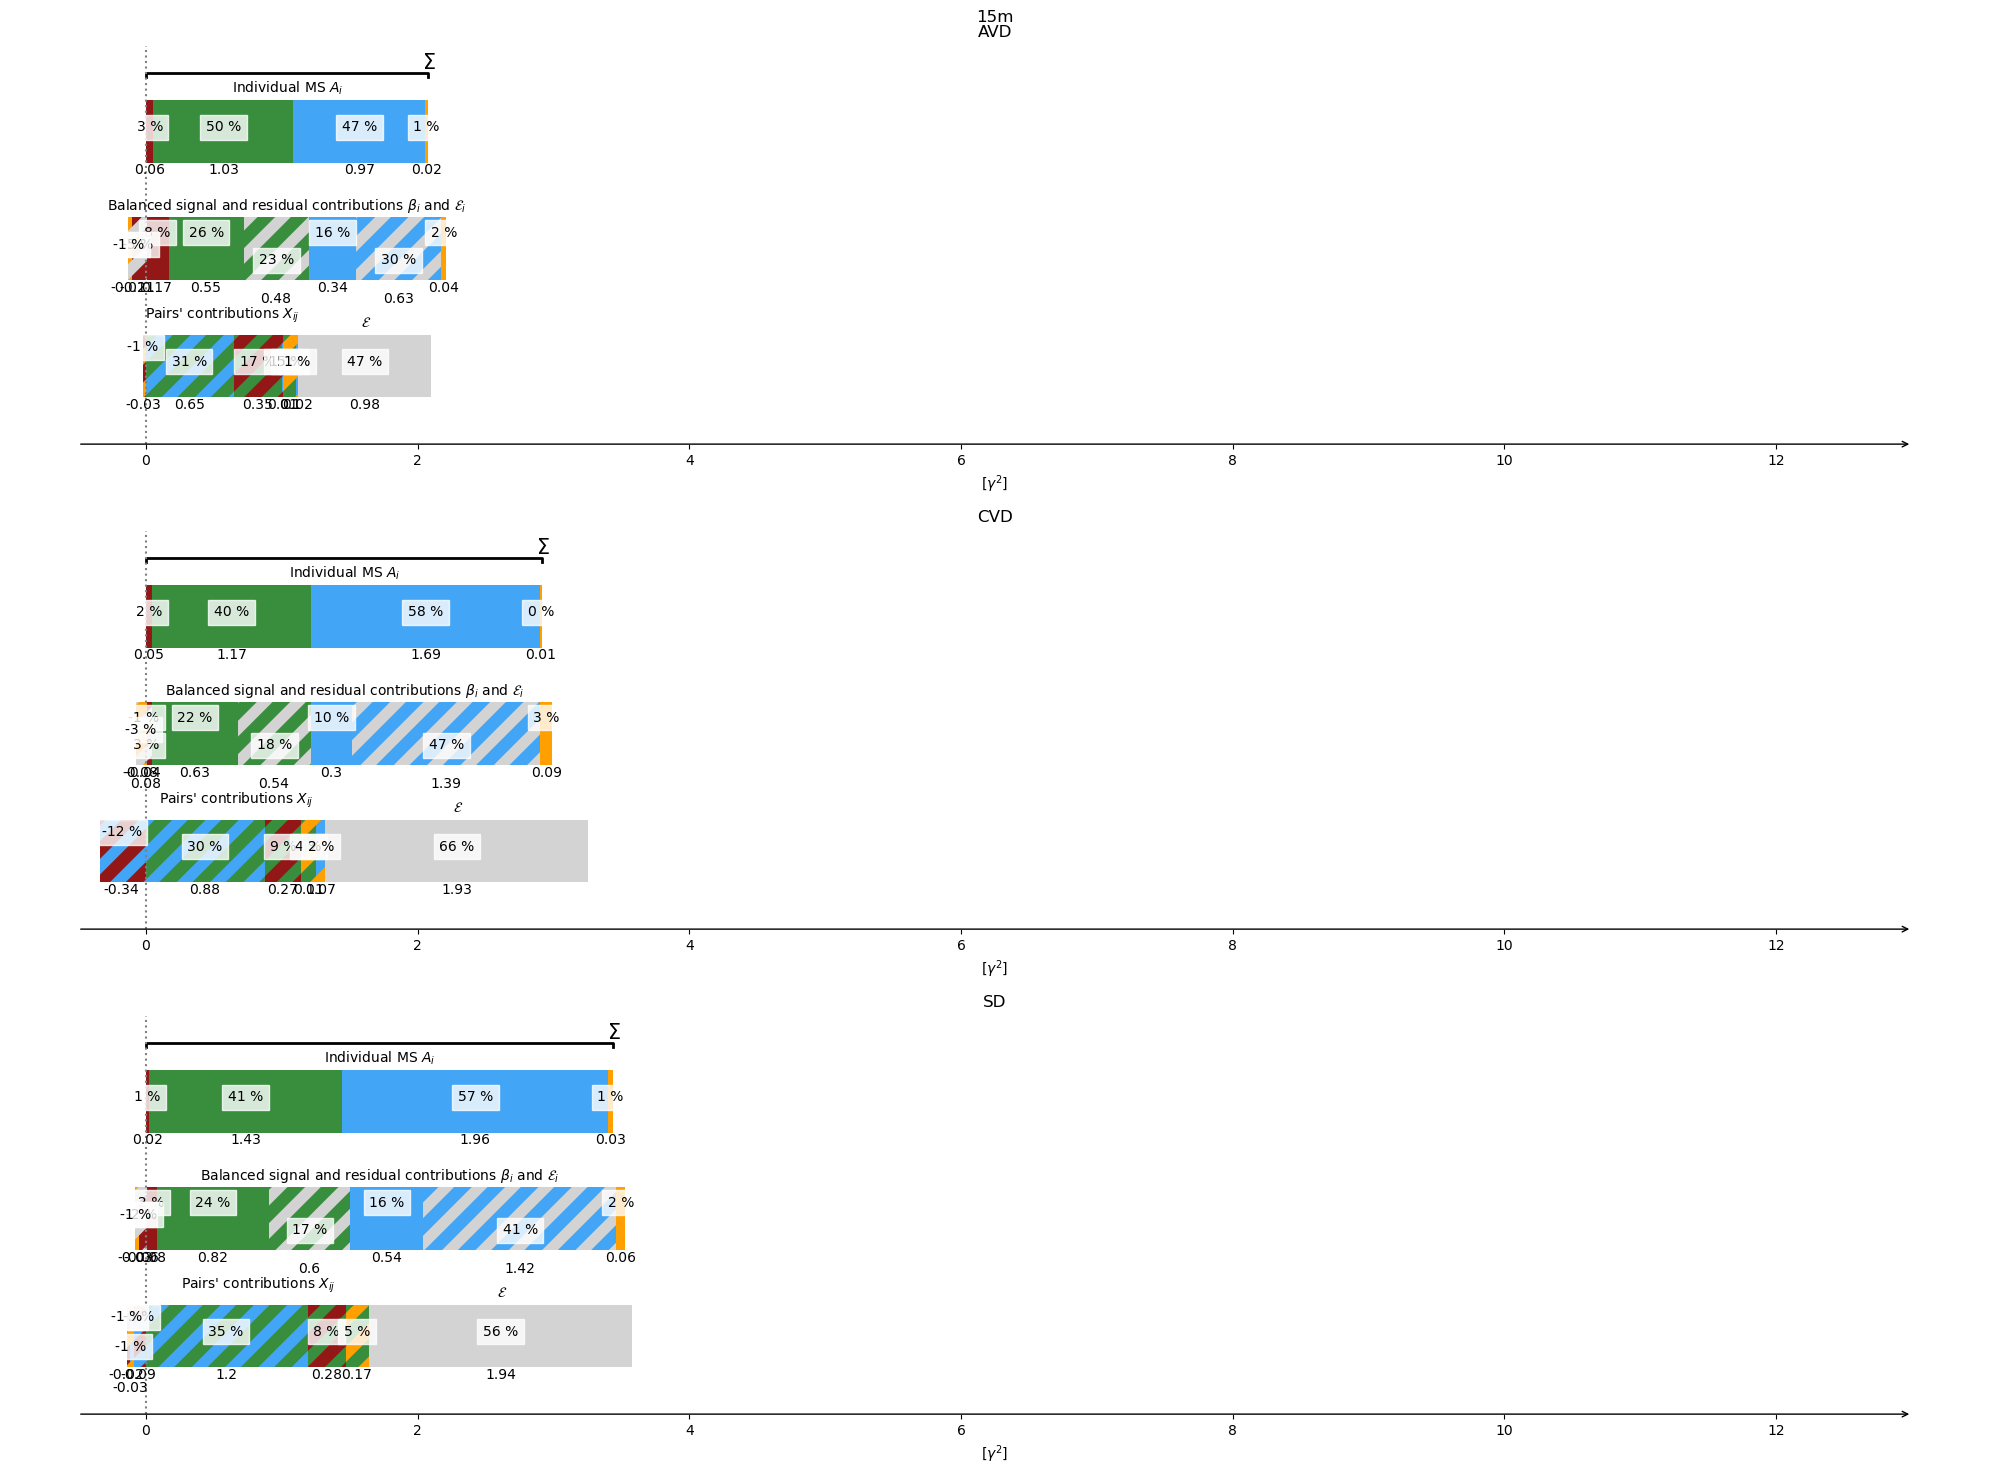

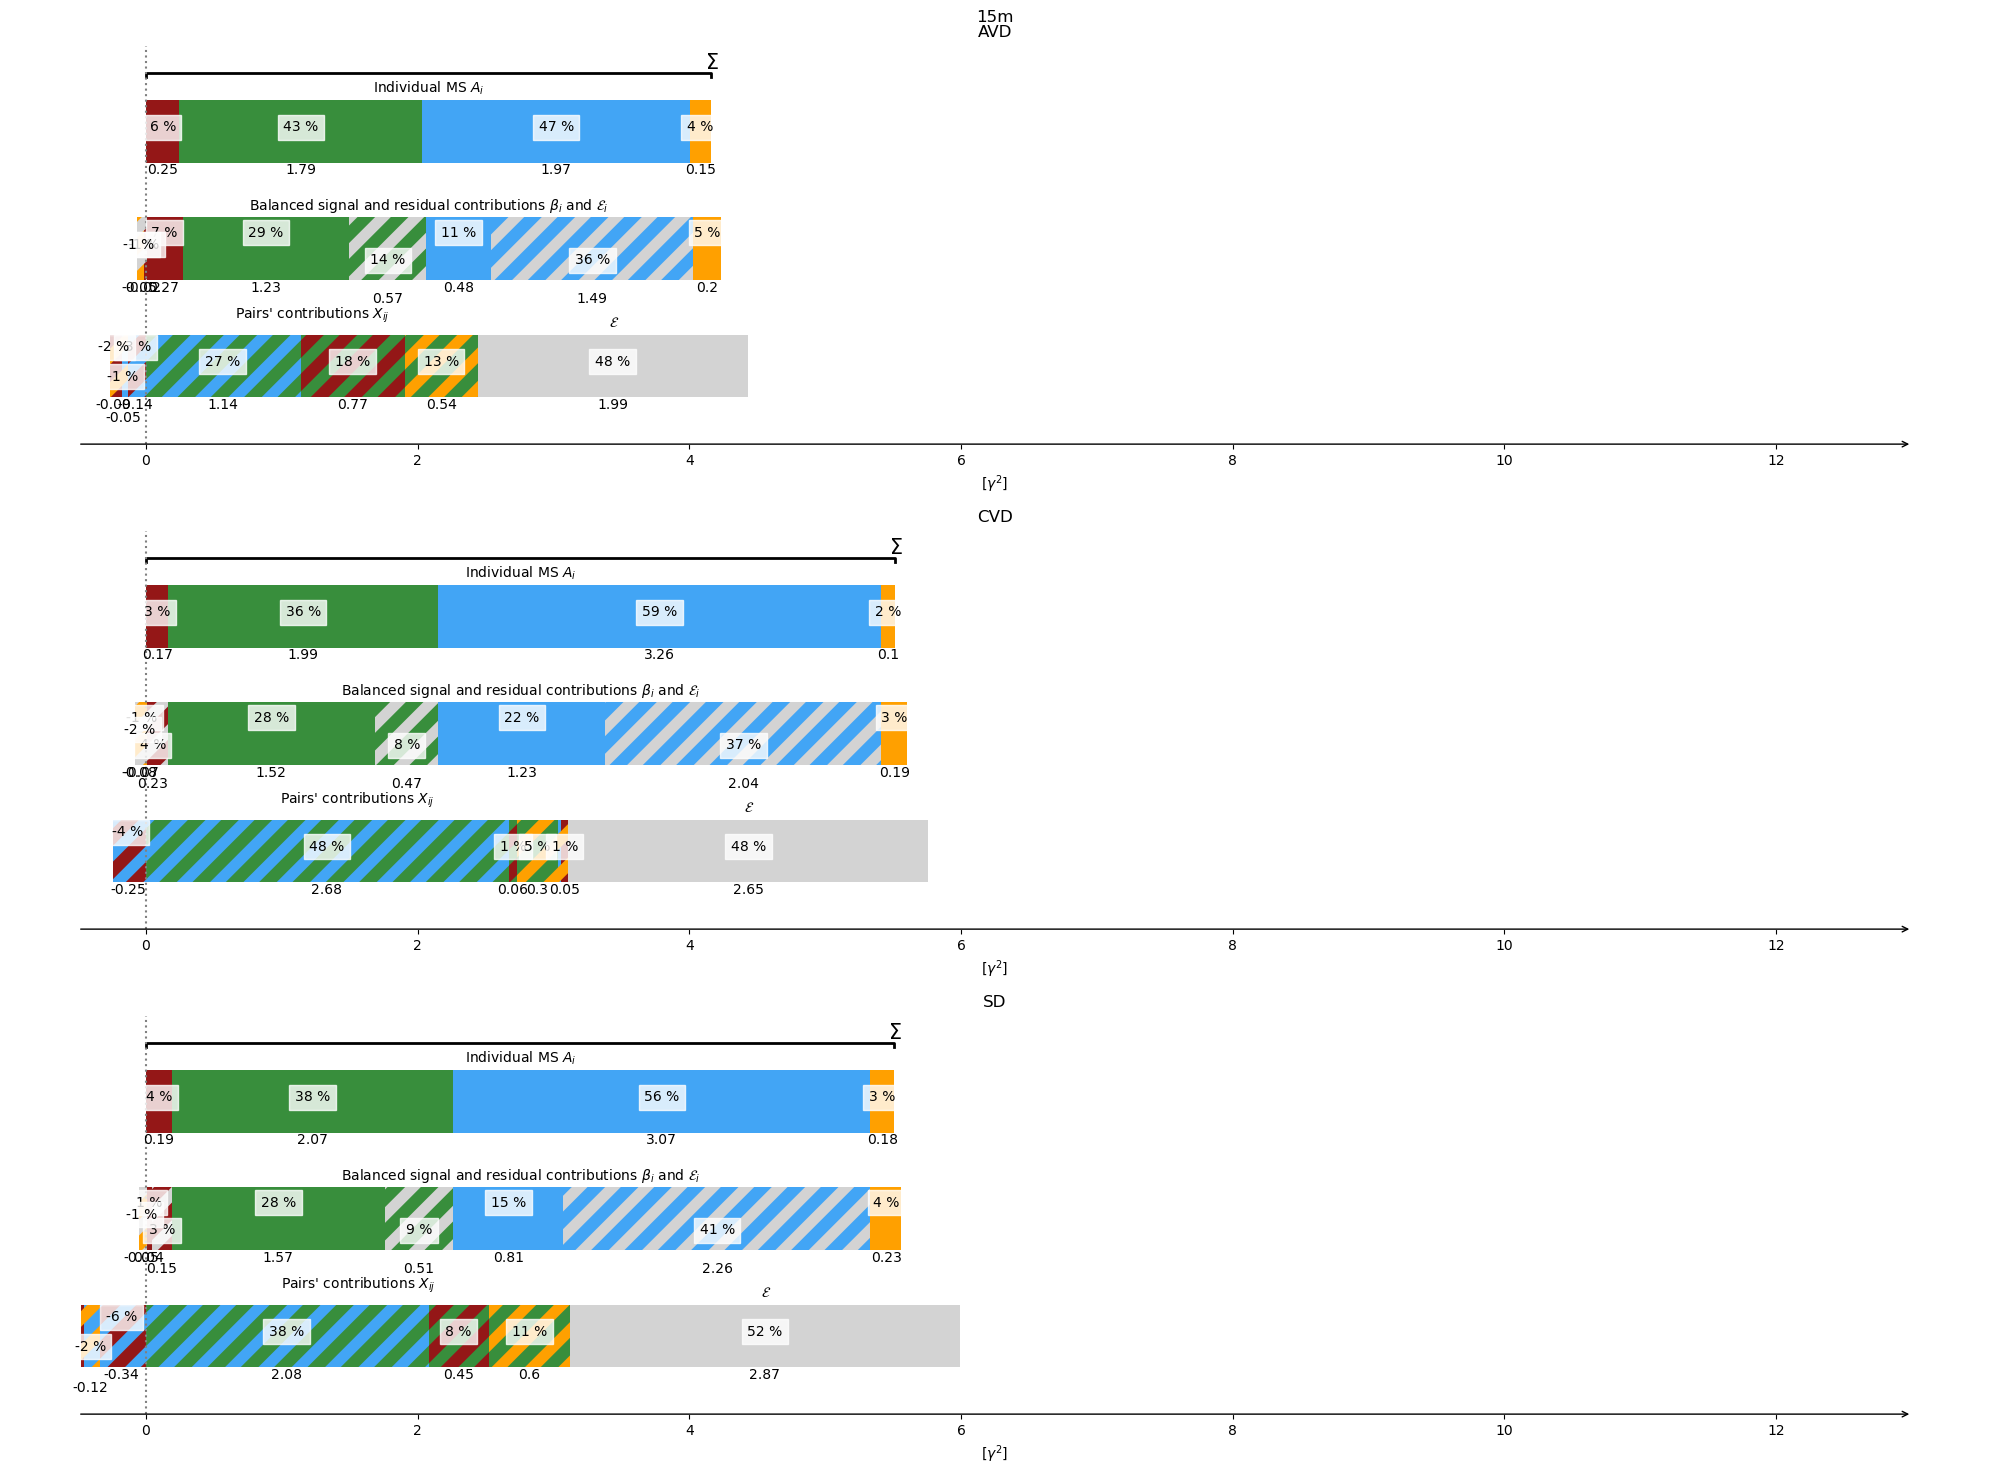

In [90]:
D = []
# Closure figs
for k in DSz15:
    print(DSz15[k].dims['row_number'])
    D.append(compute_variance(DSz15[k])/U2)
dsz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfz =dsz.to_dataframe()

plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfz.index :
    synthetic_figure(dfz.loc[d], axs[i], dir='', xlim=[-1, 13])
    axs[i].set_title(d)
    i+=1
fig.suptitle('15m')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', '15m_closure_avdcvdsd.png'))

D = []
# Closure figs
for k in DSz0:
    print(DSz0[k].dims['row_number'])
    D.append(compute_variance(DSz0[k])/U2)
dsz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfz =dsz.to_dataframe()

plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfz.index :
    synthetic_figure(dfz.loc[d], axs[i], dir='', xlim=[-1, 13])
    axs[i].set_title(d)
    i+=1
fig.suptitle('15m')
fig.tight_layout()

# Time evolution of the different components along trajectories

In [91]:
DF15 = dict()
DF0 = dict()

for spectral_band in ['', 'LF', 'inertial', 'diurnal', 'semidiurnal']:
    df0, df15 = generate_0_15m_coloc_dataframe(spectral_band)
    dfs = prepared_alti(dt='12h', 
            drifter_preprocess = '',
            drifter_preprocess_param='',
            alti_product_key='swot2km',
            alti_diff_method = 'xarray_diff' ,
            alti_diff_method_param = '')
    
    def concat(df, dfs):
        df = pd.concat([df, dfs[['vorticity_etaf', 'strain_s_etaf', 'strain_n_etaf',]]], axis=1).dropna()
        df['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
        fo = df.f.mean()
        df['strain_f'] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
        df['strain'] = df.strain_f*df.f#.assign_attrs({'long_name':r'$\sigma/|f|$'})
        df['vorticity'] = df.vorticity_etaf*df.f#.assign_attrs({'long_name':r'$\zeta/f$'})
        df['vorticity_f'] = df.vorticity_etaf#.assign_attrs({'long_name':r'$\zeta/f$'})
        df['omega'] = df.strain**2 - df.vorticity**2
        return df
    
    
    DF0[spectral_band] = sel_fastswot(concat(df0, dfs))
    DF15[spectral_band] = sel_fastswot(concat(df15, dfs))

321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1__inertial__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1__inertial__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variat

In [92]:
DF0['All'] = DF0['']
DF15['All'] = DF15['']

NameError: name 'kw' is not defined

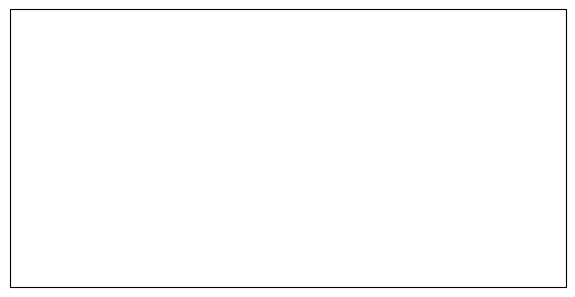

In [7]:
from matplotlib.gridspec import GridSpec
def plot_timeseries(df15, i):
    fig = plt.figure(frameon=False, figsize=(15,4))
    did = df15.drifter_id.unique()
    gs = GridSpec(2, 4, figure=fig)
    
    # Map
    ax = fig.add_subplot(gs[:, :2], projection=ccrs.PlateCarree())
    dss16.sel(cycle_number=512).etaf.plot(x='longitude', y='latitude', ax=ax, **kw)
    df_ = df15[df15.drifter_id == did[i]]
    df_.set_index('datetime').plot.scatter(x='longitude', y='latitude', s=(df_.datetime-df_.datetime.min())/pd.Timedelta('1d'), ax=ax, transform=crs, color=depthcolor[15])
    ax.set_title(did[i])
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False
    
    #Time series
    df_ =df_.set_index('datetime')
    
    ax = fig.add_subplot(gs[0, 2:],)
    for v in ['acc', 'cor', 'ggd', 'wd']:
        (df_[v+'e']/U).to_xarray().dropna('datetime').plot(ax=ax, color=c0[v], ls='', marker='.', markersize=1)
    #(df_['sum'+'e']/U).to_xarray().plot(ax=ax, color=c0['sum'], marker='.',ls='', markersize=1)
    ax.grid()
    
    ax = fig.add_subplot(gs[1, 2:],)
    for v in ['acc', 'cor', 'ggd', 'wd']:
        (df_[v+'n']/U).to_xarray().dropna('datetime').plot(ax=ax, color=c0[v], ls='', marker='.', markersize=1)
    #(df_['sum'+'n']/U).to_xarray().plot(ax=ax, color=c0['sum'], marker='.',ls='', markersize=1)
    ax.grid()
    
    fig.tight_layout()
    #fig.savefig(os.path.join(zarr_dir, 'diag_files', 'inertial_timeseries_images', did[i]+'.pdf'))
    plt.close()

#for i in range(len(df15.drifter_id.unique())):
#    plot_timeseries(df15, i)
#for i in range(len(df0.drifter_id.unique())):
#    plot_timeseries(df0, i)

6204607


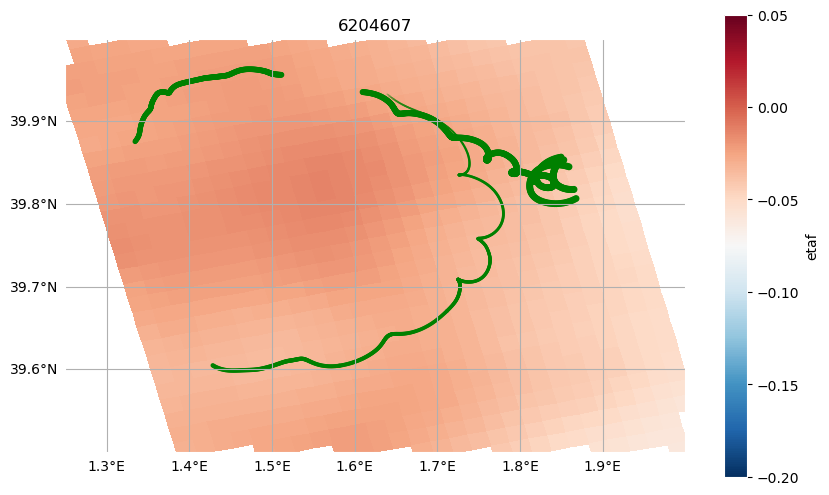

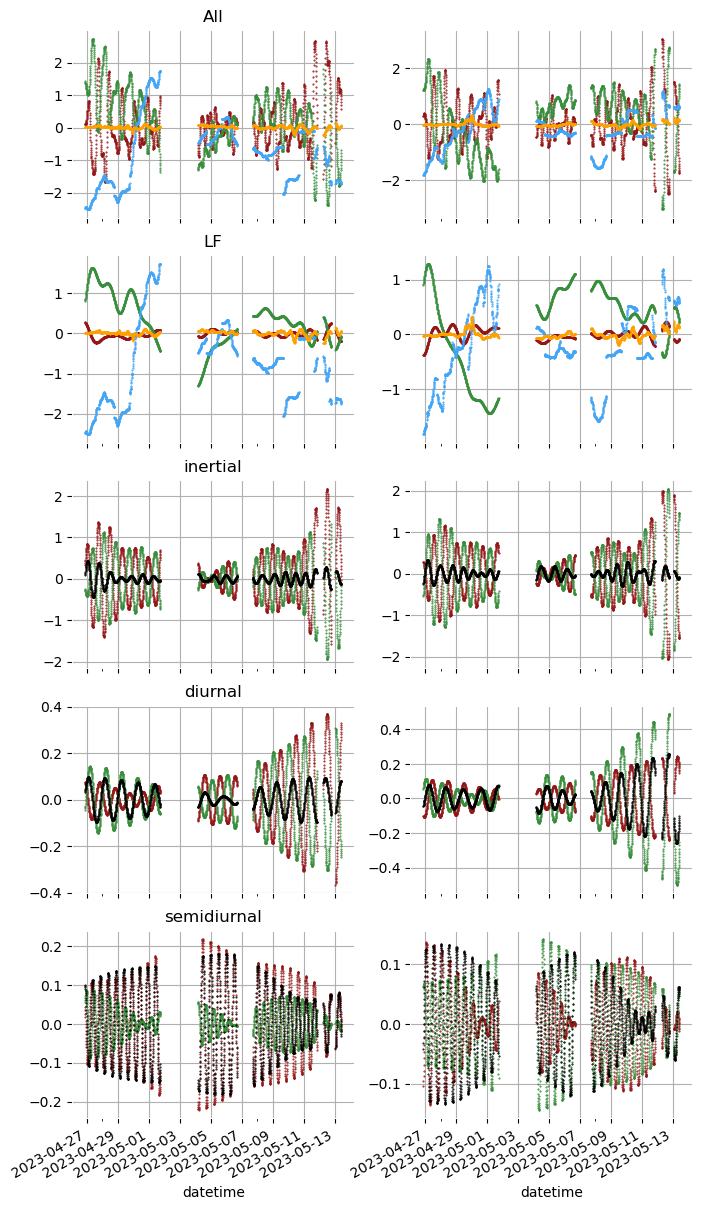

In [94]:
from matplotlib.gridspec import GridSpec
from cstes import U
def plot_timeseries_all(DF, i):
    df = DF['All']
    
    fig, ax = plt.subplots(1,1, figsize=(10,6), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()))
    did = df.drifter_id.unique()
    kw = dict(transform=crs, cmap='RdBu_r', vmin=-0.2, vmax=0.05)
    dss16.sel(cycle_number=512).etaf.plot(x='longitude', y='latitude', ax=ax, **kw)
    print(did[i])
    df_ = df[df.drifter_id == did[i]]
    df_.set_index('datetime').plot.scatter(x='longitude', y='latitude', s=(df_.datetime-df_.datetime.min())/pd.Timedelta('1d'), ax=ax, transform=crs, color=depthcolor[15])
    ax.set_title(did[i])
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False

    
    fig, axs = plt.subplots(5, 2,  figsize=(8,16), frameon=False, sharex=True)
    axs =axs.flatten()
    j = 0
    for spectral_band in ['All', 'LF'] :   
        #Time series
        df=DF[spectral_band]
        df_ = df[df.drifter_id == did[i]]
        df_ =df_.set_index('datetime')
        
        ax = axs[j]
        for v in ['acc', 'cor', 'ggd', 'wd']:
            (df_[v+'e']/U).dropna().plot(ax=ax, color=c0[v], ls='', marker='.', markersize=1)
        #(df_['sum'+'e']/U).to_xarray().plot(ax=ax, color=c0['sum'], marker='.',ls='', markersize=1)
        ax.grid()
        ax.set_title(spectral_band)
        
        ax = axs[j+1]
        for v in ['acc', 'cor', 'ggd', 'wd']:
            (df_[v+'n']/U).dropna().plot(ax=ax, color=c0[v], ls='', marker='.', markersize=1)
        #(df_['sum'+'n']/U).to_xarray().plot(ax=ax, color=c0['sum'], marker='.',ls='', markersize=1)
        ax.grid()
        j+=2

    for spectral_band in ['inertial', 'diurnal', 'semidiurnal'] :   
        #Time series
        df=DF[spectral_band]
        df_ = df[df.drifter_id == did[i]]
        df_ =df_.set_index('datetime')
        
        ax = axs[j]
        for v in ['acc', 'cor']:
            (df_[v+'e']/U).dropna().plot(ax=ax, color=c0[v], ls='', marker='.', markersize=1)
        #(df_['sum'+'e']/U).to_xarray().plot(ax=ax, color=c0['sum'], marker='.',ls='', markersize=1)
        ((df_['acce']+df_['core'])/U).dropna().plot(ax=ax, color='k', ls='', marker='.', markersize=1)
        ax.grid()
        ax.set_title(spectral_band)
        
        ax = axs[j+1]
        for v in ['acc', 'cor']:
            (df_[v+'n']/U).dropna().plot(ax=ax, color=c0[v], ls='', marker='.', markersize=1)
        ((df_['accn']+df_['corn'])/U).dropna().plot(ax=ax, color='k', ls='', marker='.', markersize=1)
        ax.grid()
        j+=2

    #fig.tight_layout()
    #fig.savefig(os.path.join(zarr_dir, 'diag_files', 'synth_timeseries_images', did[i]+'.pdf'))
    #plt.close()


plot_timeseries_all(DF15, 1)

284


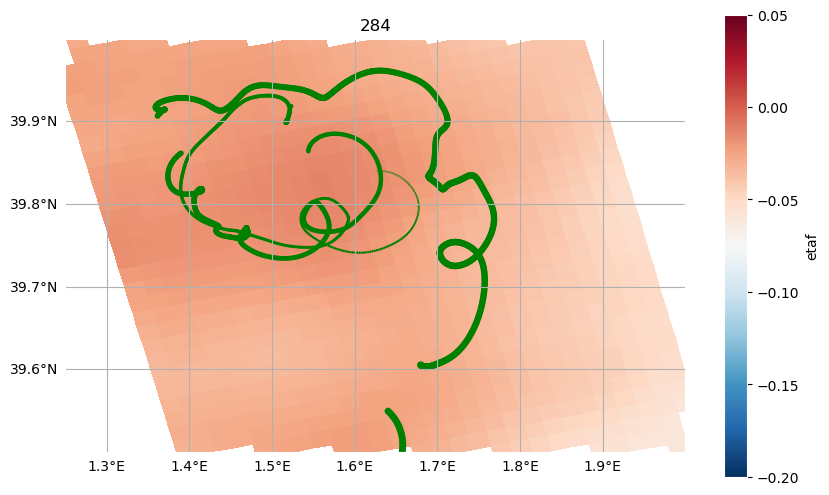

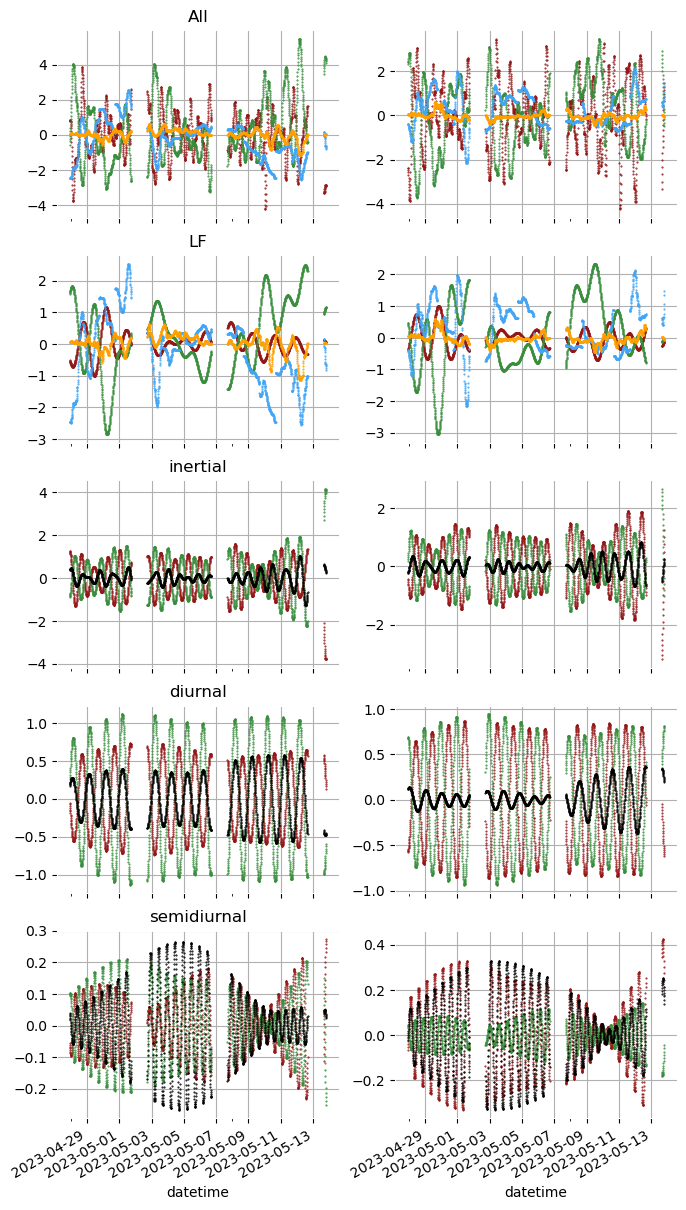

In [98]:
plot_timeseries_all(DF0,7)